In [1]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.contrib.piecewise import PiecewiseLinearFunction
from pyomo.opt import SolverFactory
from pyomo.core.base import TransformationFactory
from pyomo.opt import SolverStatus, TerminationCondition
from dataclasses import dataclass, field
from typing import Callable, List, Dict, Tuple, Optional
import numpy as np
import math
import matplotlib.pyplot as plt
import bisect
import itertools as it
from tqdm import tqdm
import csv
from pyomo.solvers.plugins.solvers.gurobi_persistent import GurobiPersistent
from typing import List, Tuple
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ----------------------- 工具函数：统一设置 Gurobi 参数 -----------------------
def apply_params(opt: GurobiPersistent):
    opt.set_gurobi_param('MIPGap',         1e-1)
    opt.set_gurobi_param('FeasibilityTol', 1e-3)
    opt.set_gurobi_param('IntFeasTol',     1e-3)
    opt.set_gurobi_param('OptimalityTol',  1e-3)
    opt.set_gurobi_param('NumericFocus',   1)
    opt.set_gurobi_param('Presolve',       2)
    opt.set_gurobi_param('NonConvex',      2)

# ----------------------- 求场景真值 v(y) -----------------------
def evaluate_Q_at(model, first_stg_vars, first_stg_vals, solver):
    del_components(model)
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(pyo.value(v))
    model.obj = pyo.Objective(expr=model.obj_expr, sense=pyo.minimize)

    try:
        # 若是 persistent，先绑定，再不传 model 求解；否则按 file-based 调用
        if hasattr(solver, "set_instance"):
            solver.set_instance(model)
            results = solver.solve(tee=False)
        else:
            results = solver.solve(model, tee=False)

        status_ok = (results.solver.status == SolverStatus.ok)
        term_ok   = (results.solver.termination_condition == TerminationCondition.optimal)
        if not (status_ok and term_ok):
            raise RuntimeError(
                f"Scenario evaluate at y={first_stg_vals} not optimal: "
                f"status={results.solver.status}, term={results.solver.termination_condition}"
            )
        return pyo.value(model.obj_expr)
    finally:
        if hasattr(model, 'obj'):
            model.del_component('obj')
        for u in first_stg_vars:
            if u.fixed:
                u.unfix()

# ----------------------- 打印辅助 -----------------------
def _fmt_item(x, prec=6):
    if isinstance(x, (tuple, list)):
        return "(" + ", ".join(f"{float(v):.{prec}f}" for v in x) + ")"
    try:
        return f"{float(x):.{prec}f}"
    except Exception:
        return str(x)

# ----------------------- warm start -----------------------
def dump_solution(m):
    return {
        'Kp': pyo.value(m.Kp),
        'Ki': pyo.value(m.Ki),
        'Kd': pyo.value(m.Kd),
        'x': {t: pyo.value(m.x[t]) for t in m.T},
        'u': {t: pyo.value(m.u[t]) for t in m.T},
        'e': {t: pyo.value(m.e[t]) for t in m.T},
        'I': {t: pyo.value(m.I[t]) for t in m.T},
    }

def apply_warm_values(m, sol):
    if not sol:
        return
    if sol.get('Kp') is not None: m.Kp.value = sol['Kp']
    if sol.get('Ki') is not None: m.Ki.value = sol['Ki']
    if sol.get('Kd') is not None: m.Kd.value = sol['Kd']
    for t in m.T:
        if 'x' in sol and t in sol['x']: m.x[t].value = sol['x'][t]
        if 'u' in sol and t in sol['u']: m.u[t].value = sol['u'][t]
        if 'e' in sol and t in sol['e']: m.e[t].value = sol['e'][t]
        if 'I' in sol and t in sol['I']: m.I[t].value = sol['I'][t]

def push_start_to_gurobi(opt, m):
    for v in m.component_data_objects(pyo.Var, active=True):
        val = v.value
        if val is None:
            continue
        if v.is_binary() or v.is_integer():
            if abs(val - round(val)) < 1e-6:
                val = int(round(val))
        if v.has_lb() and val < v.lb: val = v.lb
        if v.has_ub() and val > v.ub: val = v.ub
        opt.set_var_attr(v, "Start", float(val))

# ----------------------- 打印节点表 -----------------------
def print_nodes_row(existing_nodes, new_node,
                    existing_values=None, new_value=None,
                    prec_node=2, prec_value=6, pad=2, label_new="(new node)",
                    highlight_min=True):
    headers = [f"node{i+1}" for i in range(len(existing_nodes))] + [f"node{len(existing_nodes)+1} {label_new}"]
    node_strs = [_fmt_item(n, prec_node) for n in existing_nodes] + [_fmt_item(new_node, prec_node)]

    have_vals = existing_values is not None or new_value is not None
    if existing_values is None:
        existing_values = [None] * len(existing_nodes)

    val_strs = []
    if have_vals:
        for v in existing_values:
            val_strs.append(_fmt_item(v, prec_value) if v is not None else "")
        val_strs.append(_fmt_item(new_value, prec_value) if new_value is not None else "")

    min_val = None
    if have_vals and highlight_min:
        try:
            nums = [float(v) for v in existing_values if v is not None]
            if new_value is not None:
                nums.append(float(new_value))
            if nums:
                min_val = min(nums)
        except Exception:
            pass

    cols = max(len(headers), len(node_strs))
    widths = []
    for j in range(cols):
        pieces = []
        if j < len(headers):   pieces.append(headers[j])
        if j < len(node_strs): pieces.append(node_strs[j])
        if have_vals and j < len(val_strs): pieces.append(val_strs[j])
        w = max(len(s) for s in pieces) + pad*2
        widths.append(w)

    def _center(s, w): return s.center(w)
    def _right(s, w):  return s.rjust(w)

    header_line = "".join(_center(h, widths[i]) for i, h in enumerate(headers))
    sep_line = "".join("-" * widths[i] for i in range(len(headers)))
    print(header_line)
    print(sep_line)

    node_line = "".join(_right(s, widths[i]) for i, s in enumerate(node_strs))
    print(node_line)

    if have_vals:
        val_line_parts = []
        for i, s in enumerate(val_strs):
            if s and min_val is not None and abs(float(s) - min_val) < 1e-12:
                colored = f"\033[31m{s}\033[0m"
                val_line_parts.append(_right(colored, widths[i] + 9))
            else:
                val_line_parts.append(_right(s, widths[i]))
        print("".join(val_line_parts))

# ----------------------- 组件清理 -----------------------
def del_components(model):
    for comp in ['obj', 'As', 'pw', 'pw_fun', 'pw_As', 'pw_link']:
        if hasattr(model, comp):
            model.del_component(comp)

# ----------------------- 角点生成 -----------------------
def corners_from_bounds(firt_stg_vars):
    bounds = []
    for y in firt_stg_vars:
        lb, ub = y.lb, y.ub
        if lb is None or ub is None:
            raise ValueError(f"{y.name} 缺少上下界，无法生成角点")
        bounds.append((float(lb), float(ub)))
    return list(it.product(*[(lb, ub) for (lb, ub) in bounds]))

# ----------------------- n 维分片 -----------------------
def add_nd_piecewise(model, firt_stg_vars, points, values,
                     name="pw", relation="==", round_ndigits=12):
    if len(points) == 0:
        raise ValueError("points 不能为空")
    N = len(firt_stg_vars)
    for pt in points:
        if len(pt) != N:
            raise ValueError(f"points 中出现与 x_vars 维度不一致的点: {pt}")
    del_components(model)

    def keyize(coords):
        return tuple(round(float(c), round_ndigits) for c in coords)
    norm_points = [keyize(pt) for pt in points]

    if isinstance(values, dict):
        table = {keyize(k): float(v) for k, v in values.items()}
        miss = [pt for pt in norm_points if pt not in table]
        if miss:
            raise KeyError(f"values 缺少这些点的取值: {miss[:5]}{' ...' if len(miss)>5 else ''}")
    else:
        if len(values) != len(points):
            raise ValueError("values 长度应与 points 数量一致（或传 dict）")
        table = {pt: float(v) for pt, v in zip(norm_points, values)}

    def _f_from_table(*coords):
        return table[keyize(coords)]

    pw = PiecewiseLinearFunction(points=norm_points, function=_f_from_table, name=f"{name}_fun")
    model.add_component(pw.name, pw)
    pw_expr = pw(*firt_stg_vars)

    As = Var(name=f"{name}_As")
    model.add_component(As.name, As)
    if relation == "==":
        link = Constraint(expr=As == pw_expr)
    elif relation == ">=":
        link = Constraint(expr=As >= pw_expr)
    elif relation == "<=":
        link = Constraint(expr=As <= pw_expr)
    else:
        raise ValueError("relation 只能是 '==', '>=', '<='")
    model.add_component(f"{name}_link", link)

    TransformationFactory('contrib.piecewise.convex_combination').apply_to(model)
    return As, pw

# ----------------------- 克隆模板 -----------------------
def clone_and_get_vars(m_old, first_stage_vars):
    m_new = m_old.clone()
    first_stage_vars_new = []
    for v in first_stage_vars:
        v_new = m_new.find_component(v.name)
        if v_new is None:
            raise KeyError(f"在新模型里找不到变量 '{v.name}'")
        first_stage_vars_new.append(v_new)
    return m_new, first_stage_vars_new

# ----------------------- 去重 -----------------------
def unique_points(points, atol=1e-9):
    out = []
    for p in points:
        if not any(all(abs(a-b) <= atol for a,b in zip(p, q)) for q in out):
            out.append(p)
    return out

# ----------------------- CSV 读取 & 模型构建 -----------------------
def load_scenarios_from_csv(csv_path: str, T: Optional[int] = None,
                            sp0: float = 0.0, sp1: float = 0.5,
                            ku_col: str = "tau_us", tau_col: str = "tau_xs",
                            disturb_prefix: str = "disturbance_",
                            setpoint_change_col: str = "setpoint_change") -> Tuple[List[Dict], int]:
    scens: List[Dict] = []
    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames or []
        if T is None:
            max_idx = -1
            for name in fieldnames:
                if name.startswith(disturb_prefix):
                    try:
                        k = int(name[len(disturb_prefix):])
                        max_idx = max(max_idx, k)
                    except:
                        pass
            if max_idx < 0:
                raise ValueError(f"未找到 '{disturb_prefix}k' 格式的扰动列")
            T = max_idx

    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if ku_col not in row or tau_col not in row:
                raise KeyError(f"CSV 缺少必要列: '{ku_col}' 或 '{tau_col}'")
            Ku  = float(row[ku_col]); tau = float(row[tau_col])

            d = []
            for t in range(T+1):
                col = f"{disturb_prefix}{t}"
                if col not in row:
                    raise KeyError(f"CSV 缺少扰动列: {col}")
                d.append(float(row[col]))

            sp = [sp1]*(T+1)
            if setpoint_change_col in row and row[setpoint_change_col] != "":
                try:
                    t_star = int(float(row[setpoint_change_col]))
                    for t in range(T+1):
                        sp[t] = sp0 if t < t_star else sp1
                except:
                    pass

            scens.append({"Ku": Ku, "tau": tau, "d": d, "sp": sp})
    return scens, T

def build_pid_model(T=10, h=0.2, scen=None, weights=(1.0, 0.01),
                    bounds=None, use_cvar=False, alpha=0.95):
    assert scen is not None, "请提供一个场景字典"
    Ku, tau, d, sp = scen["Ku"], scen["tau"], scen["d"], scen["sp"]
    assert len(d) == T+1 and len(sp) == T+1

    if bounds is None:
        bounds = {}
    bx = bounds.get("x",  (-20, 20))
    bu = bounds.get("u",  (None, None))
    bKp= bounds.get("Kp", (0, 100))
    bKi= bounds.get("Ki", (0, 100))
    bKd= bounds.get("Kd", (0, 100))
    be = bounds.get("e",  (-100, 100))
    bI = bounds.get("I",  (-200, 200))

    m = pyo.ConcreteModel()
    m.T  = pyo.RangeSet(0, T)
    m.Tm = pyo.RangeSet(1, T)

    m.Kp = pyo.Var(bounds=bKp)
    m.Ki = pyo.Var(bounds=bKi)
    m.Kd = pyo.Var(bounds=bKd)

    m.x = pyo.Var(m.T, bounds=bx)
    m.u = pyo.Var(m.T, bounds=bu)
    m.e = pyo.Var(m.T, bounds=be)
    m.I = pyo.Var(m.T, bounds=bI)

    def _err_rule(m, t): return m.e[t] == sp[t] - m.x[t]
    m.err_def = pyo.Constraint(m.T, rule=_err_rule)

    def _I_dyn(m, t): return m.I[t] == m.I[t-1] + h*m.e[t]
    m.I_dyn = pyo.Constraint(m.Tm, rule=_I_dyn)

    def _x_dyn(m, t):
        return m.x[t] == m.x[t-1] + (h/tau)*(-m.x[t] + Ku*m.u[t] + d[t])
    m.x_dyn = pyo.Constraint(m.Tm, rule=_x_dyn)

    def _pid_rule(m, t):
        if t == 0:
            return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t]
        return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t] + m.Kd*(m.e[t]-m.e[t-1])/h
    m.pid = pyo.Constraint(m.T, rule=_pid_rule)

    m.x0 = pyo.Constraint(expr=m.x[0] == 0)
    m.I0 = pyo.Constraint(expr=m.I[0] == 0)

    w_e, w_u = weights
    m.cost = pyo.Expression(expr=sum(h*(w_e*m.e[t]**2 + w_u*m.u[t]**2) for t in m.T))
    m.obj_expr = pyo.Expression(expr=m.cost)
    return m, [m.Kp, m.Ki, m.Kd]

def build_models_from_csv(csv_path: str, h: float = 0.2,
                          weights=(1.0, 0.01), bounds=None,
                          sp0: float = 0.0, sp1: float = 0.5,
                          ku_col: str = "tau_us", tau_col: str = "tau_xs",
                          disturb_prefix: str = "disturbance_",
                          setpoint_change_col: str = "setpoint_change",
                          max_scenarios=None, skip=0):
    scens, T = load_scenarios_from_csv(
        csv_path=csv_path, T=None, sp0=sp0, sp1=sp1,
        ku_col=ku_col, tau_col=tau_col,
        disturb_prefix=disturb_prefix, setpoint_change_col=setpoint_change_col,
    )
    if skip or max_scenarios:
        scens = scens[skip: (skip + max_scenarios) if max_scenarios else None]

    model_list, first_stg_vars_list = [], []
    for scen in scens:
        m, yvars = build_pid_model(T=T, h=h, scen=scen, weights=weights, bounds=bounds)
        model_list.append(m)
        first_stg_vars_list.append(yvars)

    m_tmpl_list = [model_list[0], first_stg_vars_list[0]]
    return model_list, first_stg_vars_list, m_tmpl_list, T

# ----------------------- 主算法：underestimator -----------------------
def nc_underest(model_list, first_stg_vars_list, m_tmpl_list, target_nodes,
                solver, tolerance=1e-8, probs=None, persistent_solvers=None):
    assert persistent_solvers is not None and len(persistent_solvers) == len(model_list), \
        "需要传入与 model_list 同长度的 persistent_solvers 列表"

    N = len(model_list)
    if probs is None:
        probs = [1.0]*N

    as_nodes_list = [[] for _ in range(N)]
    ms_list = [None] * N
    new_nodes_list = [None] * N
    As_min_list = []
    add_node_history = []

    first_stg_nodes = corners_from_bounds(first_stg_vars_list[0])
    for i in range(N):
        as_nodes_list[i].extend(
            evaluate_Q_at(model_list[i], first_stg_vars_list[i], node, persistent_solvers[i])
            for node in first_stg_nodes
        )
    print('corner nodes are ', first_stg_nodes)
    print('as_nodes_list are ', as_nodes_list)

    if target_nodes <= len(first_stg_nodes):
        print('target_nodes number should be larger than ', len(first_stg_nodes))
        return

    print('Start from ', len(first_stg_nodes), ' corner nodes')
    print('The goal is to get ', target_nodes, ' nodes')
    k_list = []

    # 复用一个 sum_opt（每轮重绑和设参）
    sum_opt = GurobiPersistent()

    for k in tqdm(range(len(first_stg_nodes)+1, target_nodes+1), desc="Adding nodes"):
        print('##################################################')
        print('Start adding node ', k)
        k_list.append(k)

        for i in range(N):
            print('\nSolving scenario ', i)
            del_components(model_list[i])

            As, _ = add_nd_piecewise(
                model_list[i], first_stg_vars_list[i], first_stg_nodes, as_nodes_list[i],
                name="pw", relation="=="
            )
            model_list[i].obj = Objective(expr=model_list[i].obj_expr - As, sense=minimize)

            # 温启动管线
            apply_warm_values(model_list[i], warm_solutions[i])
            opt = persistent_solvers[i]
            opt.set_instance(model_list[i])     # 结构变化先重绑
            apply_params(opt)                   # 重绑后重新设参
            push_start_to_gurobi(opt, model_list[i])

            # (可选) 统计 Start 覆盖率
            n_total = n_started = 0
            for v in model_list[i].component_data_objects(pyo.Var, active=True):
                n_total += 1
                if v.value is not None:
                    n_started += 1
            print(f"[warm-start] wrote Start for {n_started}/{n_total} vars")

            results = opt.solve(tee=True)
            if (results.solver.status != SolverStatus.ok) or \
               (results.solver.termination_condition != TerminationCondition.optimal):
                print("⚠ There may be problems with the solution")

            ms_list[i] = value(model_list[i].obj)
            new_nodes_list[i] = tuple(value(v) for v in first_stg_vars_list[i])
            print('new node is ', new_nodes_list[i])
            print('ms is ', ms_list[i])

            warm_solutions[i] = dump_solution(model_list[i])

        arr = np.array(as_nodes_list, dtype=float, ndmin=2)
        assum_nodes = arr.sum(axis=0)

        print('XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX')
        print(first_stg_nodes)
        print(assum_nodes)

        model_sum, model_sum_first_stg_vars = clone_and_get_vars(m_tmpl_list[0], m_tmpl_list[1])
        del_components(model_sum)
        As_sum, pw_sum = add_nd_piecewise(
            model_sum, model_sum_first_stg_vars, first_stg_nodes, assum_nodes,
            name="pw", relation="=="
        )
        model_sum.obj = Objective(expr=As_sum, sense=minimize)

        # sum_opt：先绑定再设参
        sum_opt.set_instance(model_sum)
        apply_params(sum_opt)
        results = sum_opt.solve(tee=True)
        if not ((results.solver.status == SolverStatus.ok) and
                (results.solver.termination_condition == TerminationCondition.optimal)):
            print("Sum model doesn't get solved normally")

        As_min = results.problem.lower_bound
        print(f'As_min at possible new node is {As_min}')
        node_star = tuple(value(v) for v in model_sum_first_stg_vars)

        if (node_star is None) or (node_star in first_stg_nodes):
            avg = []
            for j in range(len(first_stg_nodes[0])):
                comp_vals = [node[j] for node in first_stg_nodes]
                avg.append(sum(comp_vals) / len(comp_vals))
            node_star = tuple(avg)
            As_min = value(pw_sum(*node_star))

        q_node_star = 0.0
        for i in range(N):
            q_node_star += evaluate_Q_at(model_list[i], first_stg_vars_list[i], node_star, persistent_solvers[i])
        print(f'Real value at possible new node is {q_node_star}')
        errors_node_star = abs(As_min - q_node_star)
        print(f'error at possible new node is {errors_node_star}')

        sum_ms = sum(ms_i for ms_i in ms_list)

        print('Sum *****************************************')
        print('error at y_star is ', errors_node_star)
        print('y_star is ', node_star)
        print('ms_list and sum_ms is ', ms_list, sum_ms)

        if errors_node_star > abs(sum_ms):
            new_node = node_star
            print('new node choosen from error')
        else:
            min_index = int(np.argmin(ms_list))
            new_node = new_nodes_list[min_index]
            print('new node choosen from ms')

        As_min_list.append(As_min + sum_ms)
        add_node_history.append(new_node)
        print_nodes_row(first_stg_nodes, new_node,
                        existing_values=assum_nodes,
                        new_value=q_node_star,
                        prec_node=1,
                        prec_value=6)
        print('new node is', new_node)
        print('Current As_min is', As_min_list[-1])
        print('*****************************************\n')

        print('current nodes are ', first_stg_nodes)
        print('as_nodes_list are ', as_nodes_list)
        print('new_node is', new_node)
        first_stg_nodes.append(new_node)
        for i in range(N):
            as_val = evaluate_Q_at(model_list[i], first_stg_vars_list[i], new_node, persistent_solvers[i])
            as_nodes_list[i].append(as_val)

        arr = np.array(as_nodes_list, dtype=float, ndmin=2)
        assum_nodes = arr.sum(axis=0)

        idx = int(np.argmin(assum_nodes))
        val = assum_nodes[idx]
        print(f"\033[31mcurrent node is {idx+1} node, value is {val:.6f}\033[0m")
        print(f"node is {first_stg_nodes[idx]}")

    arr = np.array(as_nodes_list, dtype=float, ndmin=2)
    assum_nodes = arr.sum(axis=0)

    model_sum, model_sum_first_stg_vars = clone_and_get_vars(m_tmpl_list[0], m_tmpl_list[1])
    del_components(model_sum)
    As_sum, _ = add_nd_piecewise(
        model_sum, model_sum_first_stg_vars, first_stg_nodes, assum_nodes,
        name="pw", relation="=="
    )
    model_sum.obj = Objective(expr=As_sum, sense=minimize)

    sum_opt.set_instance(model_sum)
    apply_params(sum_opt)
    results = sum_opt.solve(tee=True)
    if not ((results.solver.status == SolverStatus.ok) and
            (results.solver.termination_condition == TerminationCondition.optimal)):
        print("Sum model doesn't get solved normally")

    output_lb = results.problem.lower_bound + sum(ms_list)
    print('lower bound is ', output_lb)
    print('node is ', tuple(value(v) for v in model_sum_first_stg_vars))

    return output_lb, first_stg_nodes, [k_list, As_min_list, add_node_history]

# ----------------------- main -----------------------
if __name__ == "__main__":
    csv_path = "data.csv"
    max_scenarios = 3
    weights = (1.0, 0.01)
    bounds = {
        "x": (-1e3, 1e3),
        "u": (None, None),
        "e": (-1e3, 1e3),
        "I": (-1e5, 1e5),
        "Kp": (0, 100),
        "Ki": (0, 100),
        "Kd": (0, 100),
    }

    model_list, first_stg_vars_list, m_tmpl_list, T = build_models_from_csv(
        csv_path, h=0.2, weights=weights, bounds=bounds,
        sp0=0.0, sp1=0.5, ku_col="tau_us", tau_col="tau_xs",
        disturb_prefix="disturbance_", setpoint_change_col="setpoint_change",
        max_scenarios=max_scenarios, skip=0
    )

    # persistent 求解器：每个场景一个——先 set_instance，再设参数
    persistent_solvers = [GurobiPersistent() for _ in model_list]
    for j, m in enumerate(model_list):
        opt = persistent_solvers[j]
        opt.set_instance(m)
        apply_params(opt)

    # warm start 存储
    global warm_solutions
    warm_solutions = [None for _ in model_list]

    # 可保留一个普通 solver（evaluate_Q_at 在非 persistent 下也能跑）
    solver = SolverFactory('gurobi')
    solver.options.update({
        'MIPGap': 1e-1,
        'FeasibilityTol': 1e-3,
        'IntFeasTol':     1e-3,
        'OptimalityTol':  1e-3,
        'NumericFocus':   1,
        'Presolve':       2,
        'NonConvex':      2,
    })

    target_nodes = 30
    lb, y_nodes, history = nc_underest(
        model_list, first_stg_vars_list, m_tmpl_list,
        target_nodes=target_nodes,
        solver=solver,
        tolerance=1e-8, probs=None,
        persistent_solvers=persistent_solvers
    )
    print("LB:", lb)


Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
corner nodes are  [(0.0, 0.0, 0.0), (0.0, 0.0, 100.0), (0.0, 100.0, 0.0), (0.0, 100.0, 100.0), (100.0, 0.0, 0.0), (100.0, 0.0, 100.0), (100.0, 100.0, 0.0), (100.0, 100.0, 100.0)]
as_nodes_list are

Adding nodes:   0%|          | 0/22 [00:00<?, ?it/s]

##################################################
Start adding node  9

Solving scenario  0
Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
[warm-start] wrote Start for 87/103 vars
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (22631.2))

CPU model: AMD Ryzen 9 7900X 12-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Academic license 2689754 - for non-commercial use only - registered to yi___@math.ubc.ca
Optimize a model with 76 rows, 103 columns and 222 nonzeros
Model fingerprint: 0xd3714726
Model has 42 quadratic objective terms
Model has 21 quadratic constraints
Variable types: 97 continuous, 6 integer (6 binary)
Coefficient statistics:
  Matrix range    

Adding nodes:   5%|▍         | 1/22 [00:00<00:07,  2.81it/s]

current node is 3 node, value is 0.356290
node is (0.0, 100.0, 0.0)
##################################################
Start adding node  10

Solving scenario  0
Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
[warm-start] wrote Start for 102/121 vars
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (22631.2))

CPU model: AMD Ryzen 9 7900X 12-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Academic license 2689754 - for non-commercial use only - registered to yi___@math.ubc.ca
Optimize a model with 90 rows, 121 columns and 297 nonzeros
Model fingerprint: 0x6cbc1fdf
Model has 42 quadratic objective terms
Model has 21 quadratic constraints
Variable types: 107 cont

...

current node is 3 node, value is 0.356290
node is (0.0, 100.0, 0.0)
##################################################
Start adding node  12

Solving scenario  0
Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
[warm-start] wrote Start for 143/170 vars
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (22631.2))

CPU model: AMD Ryzen 9 7900X 12-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Academic license 2689754 - for non-commercial use only - registered to yi___@math.ubc.ca
Optimize a model with 123 rows, 170 columns and 531 nonzeros
Model fingerprint: 0xebeb34a3
Model has 42 quadratic objective terms
Model has 21 quadratic constraints
Variable types: 130 con

Adding nodes:  18%|█▊        | 4/22 [00:04<00:26,  1.48s/it]

current node is 3 node, value is 0.356290
node is (0.0, 100.0, 0.0)
##################################################
Start adding node  13

Solving scenario  0
Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
[warm-start] wrote Start for 169/201 vars
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (22631.2))

CPU model: AMD Ryzen 9 7900X 12-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Academic license 2689754 - for non-commercial use only - registered to yi___@math.ubc.ca
Optimize a model with 141 rows, 201 columns and 681 nonzeros
Model fingerprint: 0x996d0aba
Model has 42 quadratic objective terms
Model has 21 quadratic constraints
Variable types: 143 con

Adding nodes:  23%|██▎       | 5/22 [00:06<00:28,  1.66s/it]

current node is 3 node, value is 0.356290
node is (0.0, 100.0, 0.0)
##################################################
Start adding node  14

Solving scenario  0
Set parameter MIPGap to value 0.1
Set parameter FeasibilityTol to value 0.001
Set parameter IntFeasTol to value 0.001
Set parameter OptimalityTol to value 0.001
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
[warm-start] wrote Start for 200/234 vars
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (22631.2))

CPU model: AMD Ryzen 9 7900X 12-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Academic license 2689754 - for non-commercial use only - registered to yi___@math.ubc.ca
Optimize a model with 160 rows, 234 columns and 840 nonzeros
Model fingerprint: 0x74019d1d
Model has 42 quadratic objective terms
Model has 21 quadratic constraints
Variable types: 157 con

     k        LB        UB       GAP
0    9 -5.492674  1.054935  6.547609
1   10 -4.786250  1.210165  5.996415
2   11 -3.959174  1.751150  5.710324
3   12 -4.982130  1.199858  6.181988
4   13 -5.581935  1.241495  6.823430
5   14 -1.422110  3.706973  5.129083
6   15 -2.457243  3.731147  6.188390
7   16 -5.106799  1.685884  6.792682
8   17 -1.505024  4.144636  5.649659
9   18  0.632694  6.438200  5.805506
10  19 -0.720966  6.556531  7.277497
11  20 -2.395509  3.557949  5.953458


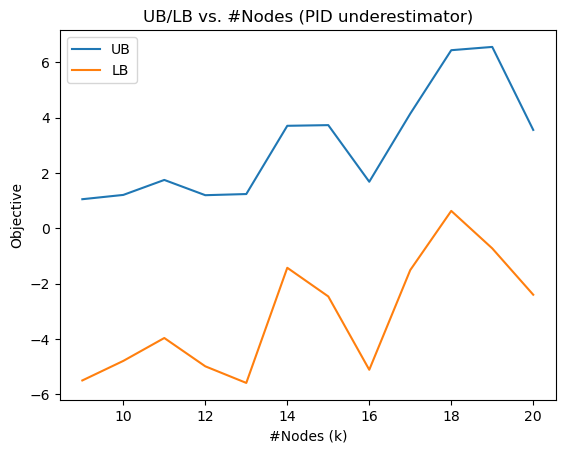

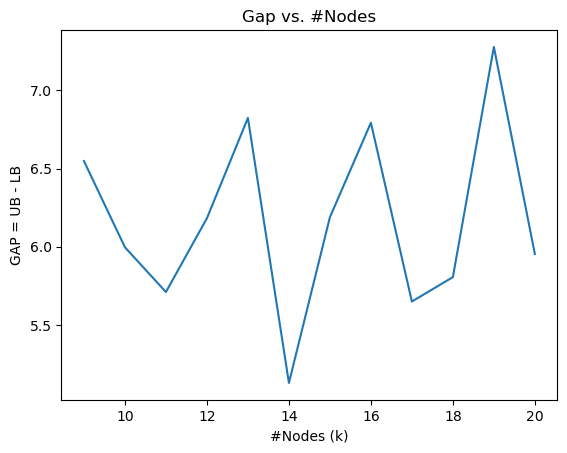

In [5]:
def compute_history_curves(model_list, first_stg_vars_list, persistent_solvers, history
                           ) -> pd.DataFrame:
    """
    history: [k_list, As_min_list, add_node_history]
      - k_list:          [k1, k2, ...]    （第几个新增节点，通常是 9,10,...）
      - As_min_list:     [LB1, LB2, ...]  （你代码里 append 的 As_min + sum_ms）
      - add_node_history:[y_new^1, y_new^2, ...] 新增的节点坐标（tuple）
    返回一个 DataFrame，包含 k, LB, UB, GAP=UB-LB
    """
    k_list, LB_list, add_node_history = history
    UB_list = []
    for y_new in add_node_history:
        ub = 0.0
        for i in range(len(model_list)):
            ub += evaluate_Q_at(
                model_list[i], first_stg_vars_list[i], y_new, persistent_solvers[i]
            )
        UB_list.append(ub)

    df = pd.DataFrame({
        "k":   k_list,
        "LB":  LB_list,
        "UB":  UB_list,
    })
    df["GAP"] = df["UB"] - df["LB"]
    return df

def plot_history_curves(df: pd.DataFrame, title: str = "UB/LB vs. #Nodes"):
    # 只用 matplotlib，且每个图单独一张（按你的要求）
    plt.figure()
    plt.plot(df["k"], df["UB"], label="UB")
    plt.plot(df["k"], df["LB"], label="LB")
    plt.xlabel("#Nodes (k)")
    plt.ylabel("Objective")
    plt.title(title)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(df["k"], df["GAP"])
    plt.xlabel("#Nodes (k)")
    plt.ylabel("GAP = UB - LB")
    plt.title("Gap vs. #Nodes")
    plt.show()

# ===== 用法 =====
df_hist = compute_history_curves(model_list, first_stg_vars_list, persistent_solvers, history)
print(df_hist)          # 表格查看
plot_history_curves(df_hist, title="UB/LB vs. #Nodes (PID underestimator)")
